# Métricas de desempeño: regresión y clasificación

Ejercicio basado en datos ficticios para practicar MAE, MSE, RMSE, R², matriz de confusión y curva ROC-AUC.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, accuracy_score, precision_score, recall_score,
    roc_curve, roc_auc_score
)


## 1. Métricas de regresión

Calculamos MAE, MSE, RMSE y R² para precios reales vs. predichos.

In [5]:
# Datos de regresión
y_real_reg = [20000, 25000, 30000, 22000, 27000]
y_pred_reg = [19500, 24000, 31000, 23000, 26500]

# Cálculo de métricas
mae = mean_absolute_error(y_real_reg, y_pred_reg)
mse = mean_squared_error(y_real_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_real_reg, y_pred_reg)

print('Métricas de Regresión:')
print(f'MAE : {mae:.2f}')
print(f'MSE : {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²  : {r2:.4f}')

Métricas de Regresión:
MAE : 800.00
MSE : 700000.00
RMSE: 836.66
R²  : 0.9443


## 2. Métricas de clasificación

Construimos la matriz de confusión y calculamos exactitud, precisión, sensibilidad y especificidad.

In [6]:
# Datos de clasificación (clase positiva = 1)
y_real_clf = [1, 0, 1, 0, 1]
y_pred_clf = [1, 0, 0, 0, 1]

# Matriz de confusión
cm = confusion_matrix(y_real_clf, y_pred_clf)

# Métricas básicas
accuracy = accuracy_score(y_real_clf, y_pred_clf)
precision = precision_score(y_real_clf, y_pred_clf)
recall = recall_score(y_real_clf, y_pred_clf)  # sensibilidad

# Especificidad = VN / (VN + FP)
vn = cm[0, 0]
fp = cm[0, 1]
specificity = vn / (vn + fp)

print('Matriz de confusión:')
print(cm)
print('Métricas de Clasificación:')
print(f'Exactitud    (accuracy)    : {accuracy:.2f}')
print(f'Precisión    (precision)   : {precision:.2f}')
print(f'Sensibilidad (recall/TPR) : {recall:.2f}')
print(f'Especificidad (TNR)       : {specificity:.2f}')

Matriz de confusión:
[[2 0]
 [1 2]]
Métricas de Clasificación:
Exactitud    (accuracy)    : 0.80
Precisión    (precision)   : 1.00
Sensibilidad (recall/TPR) : 0.67
Especificidad (TNR)       : 1.00


## 3. Curva ROC y AUC

Usamos probabilidades predichas para la clase positiva y calculamos la curva ROC y el AUC.

Puntos ROC:
umbral=inf, FPR=0.00, TPR=0.00
umbral=0.90, FPR=0.00, TPR=0.33
umbral=0.70, FPR=0.00, TPR=1.00
umbral=0.35, FPR=1.00, TPR=1.00
AUC: 1.000


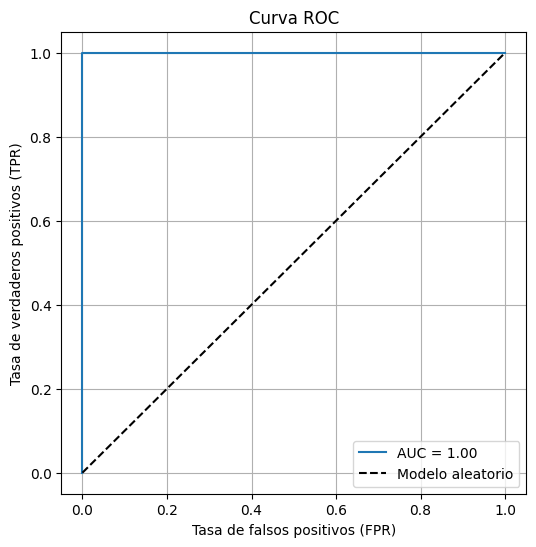

In [8]:
# Probabilidades para la clase positiva
y_proba_clf = [0.90, 0.40, 0.80, 0.35, 0.70]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_real_clf, y_proba_clf)
auc = roc_auc_score(y_real_clf, y_proba_clf)

print('Puntos ROC:')
for thr, f, t in zip(thresholds, fpr, tpr):
    print(f"umbral={thr:.2f}, FPR={f:.2f}, TPR={t:.2f}")
print(f"AUC: {auc:.3f}")

# Gráfico ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Modelo aleatorio')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
